In [1]:
from CADETProcess.optimization import OptimizationProblem
from CADETProcess.processModel import Inlet, MCT, Outlet, Cstr
from CADETProcess.optimization import SLSQP, U_NSGA3, Pathos, Joblib, COBYLA, TrustConstr
from CADETProcess.processModel import ComponentSystem,MassActionLaw, LumpedRateModelWithoutPores
from CADETProcess.processModel import FlowSheet
from CADETProcess.processModel import Process
from CADETProcess.simulator import Cadet
from scipy.optimize import minimize

import logging

from IPython import display

from utils import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
dfuplow = process_roi_txt_to_excel("lowupbranch.txt", "lowupbranch.xlsx")
dfuplow = dfuplow.iloc[:]

dfside = process_roi_txt_to_excel("sidebranch.txt", "sidebranch.xlsx")
dfside = dfside.iloc[:]

dfupside = process_roi_txt_to_excel("upsidebranch.txt", "upsidebranch.xlsx")
dfupside = dfupside.iloc[:]



In [3]:
dfuplow, dfside

(             0.000          11.265         22.512         33.802   \
 0.0       192.062141     179.281212     172.301201     142.569065   
 5.0       284.265733     274.888559     245.233808     224.666764   
 10.0      271.282023     250.769903     230.446810     183.687425   
 15.0      262.640575     250.687113     205.098878     191.769538   
 20.0     1029.536886     737.093144     490.689975     233.222833   
 25.0    19197.406822   16129.916245   16282.591740    3615.790593   
 30.0    68255.918418   67958.709247   88466.692785   28002.308283   
 35.0   130931.114481  144987.824123  235161.900591   96385.862833   
 40.0   179665.797315  210421.597411  391499.431661  196993.937980   
 45.0   211228.626165  252756.345279  510747.748257  293055.283064   
 50.0   229968.680201  278488.802360  586578.097545  367267.510356   
 55.0   243114.808191  292699.787745  629487.005934  418496.127351   
 60.0   251611.876859  299239.727246  654890.074847  453175.443519   
 65.0   257698.71363

In [4]:
def pad_with_leading_zeros_and_extend_time(exp_data, time, n_pad, dt=None):
    """
    Add n_pad zero rows to the FRONT of exp_data and add n_pad new time steps to the END of time.
    Shapes stay aligned: new_data.shape[0] == new_time.shape[0] == len(time) + n_pad

    exp_data: (T, C)
    time: (T,)
    n_pad: int >= 0
    dt: step size; if None, inferred from time (assumes uniform spacing)
    """
    exp_data = np.asarray(exp_data)
    time = np.asarray(time)

    T, C = exp_data.shape
    if dt is None:
        if len(time) < 2:
            raise ValueError("Cannot infer dt from a time array with <2 elements.")
        dt = time[1] - time[0]

    # pad data at the front with zeros
    zeros_front = np.zeros((n_pad, C))
    exp_data_padded = np.vstack([zeros_front, exp_data])  # (T + n_pad, C)

    # extend time at the end only'
    extra_times = time[-1] + np.arange(1, n_pad + 1) * dt
    time_padded = np.concatenate([time, extra_times])     # (T + n_pad,)

    # sanity check: aligned lengths
    assert exp_data_padded.shape[0] == time_padded.shape[0]

    return exp_data_padded, time_padded

# ---- example ----
# exp_data: (41, 12), time: [0, 5, 10, ..., 200]
# n_pad = 3 -> new shapes: (44, 12) and (44,)
# first 3 rows are zeros at times [0, 5, 10]; original data is effectively shifted right by 3 steps
# time extends to [ ..., 205, 210, 215]
# exp_data_padded, time_padded = pad_with_leading_zeros_and_extend_time(exp_data, time, n_pad=3)


In [5]:
xiuplow=list(dfuplow.columns)
xiuplow = np.array(xiuplow)[[3,4,5,6,11,12,13,14]]
t=dfuplow.index.to_numpy()

data_cor_uplow=dfuplow[xiuplow].to_numpy(dtype=float)

data_unc_uplow=dfuplow[xiuplow].to_numpy(dtype=float)*np.exp(-0.000567*60*t.reshape(len(t),1))

xiside=list(dfside.columns)
xiside = xiside[1:5]
xi_side = xiside
t=dfside.index.to_numpy()


data_cor_side=dfside[xiside].to_numpy(dtype=float)

data_unc_side=dfside[xiside].to_numpy(dtype=float)*np.exp(-0.000567*60*t.reshape(len(t),1))


orig_exp_data_up = data_cor_uplow[:, 0:4]
orig_exp_data_side = data_cor_side
orig_exp_data_low = data_cor_uplow[:, 4:]

xi_up_end = np.array(xiuplow)[3]
xi_up = np.array(xiuplow)[0:4]-np.array(xiuplow)[0]
xi_low_start = np.array(xiuplow)[4]
xi_low = np.array(xiuplow)[4:]-np.array(xiuplow)[4]
xi_side = np.array(xi_side)-xi_side[0]


exp_data = np.hstack((data_unc_uplow[:, 0:4],data_unc_side,data_unc_uplow[:, 4:]))
exp_data = exp_data/np.max(exp_data)

exp_data, t = pad_with_leading_zeros_and_extend_time(exp_data, t, 0)


In [6]:

exp_data.shape, t.shape

((42, 12), (42,))

In [7]:
np.array(xiuplow)[0:4], xi_up_end

(array([33.802, 45.115, 56.427, 67.739]), np.float64(67.739))

In [8]:
exp_data.shape

(42, 12)

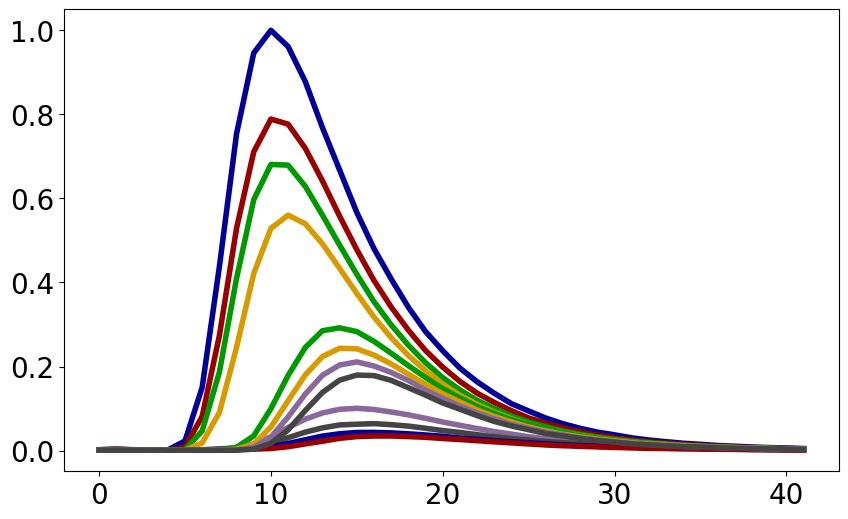

In [9]:
plt.plot(exp_data)

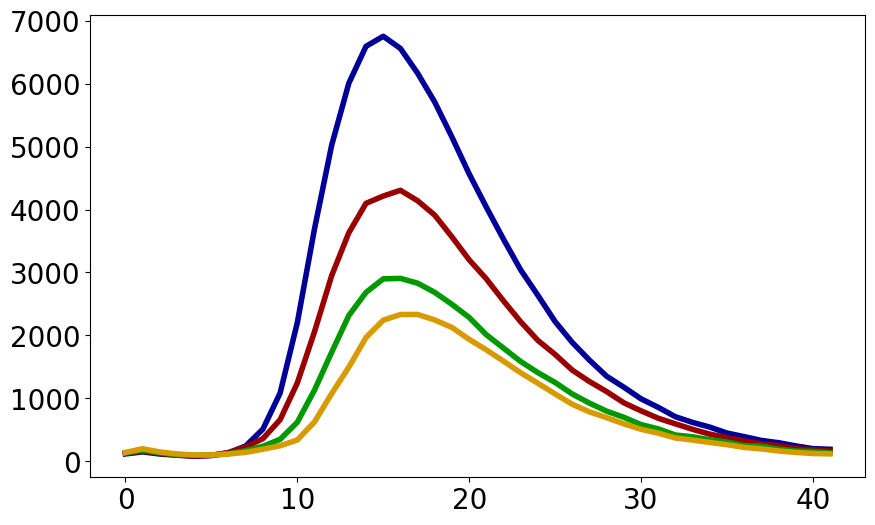

In [10]:

plt.plot(data_unc_side)
#plt.plot(data_unc_uplow)

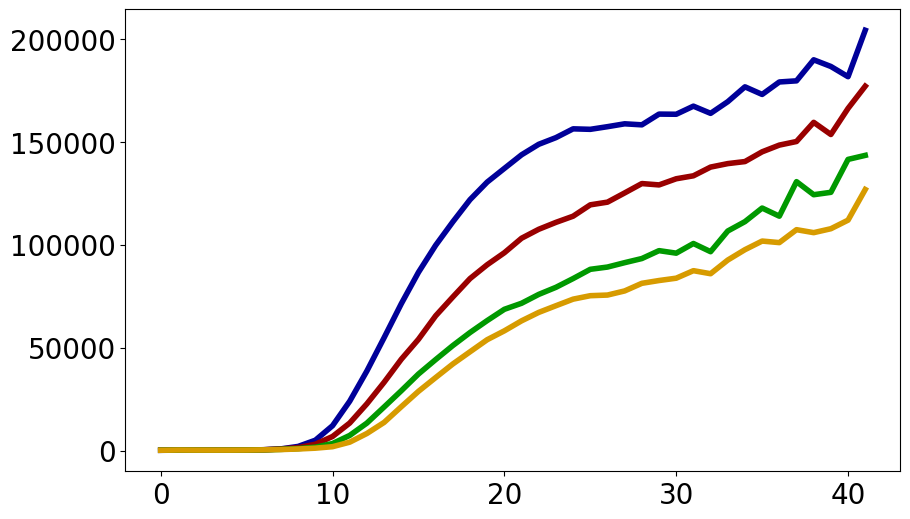

In [11]:
#plt.plot(orig_exp_data_up)
plt.plot(orig_exp_data_side)
#plt.plot(orig_exp_data_low)

In [12]:
xi_low

array([ 0.   , 11.313, 22.624, 33.927])

In [13]:
def setup_process(x):
    
    p_volumetric_flow_rate_const = x[0]
    p_mct1_e12 = x[1]
    p_mct2_e12 = x[2]
    p_mct3_e12 = x[3]
    branch_point_side_quotia = x [4]
    p_col_dispersion = x[5]
    p_col_len = x[6]
    p_t0 = x[7]
    p_mixer_porosity = x[8]
    branch_point_low_len = x[9]
    disp_low = x[10]
    
    
  # Initialize the component system and flow sheet
    component_system = ComponentSystem(1)
    mct_flow_sheet = FlowSheet(component_system)

    # Create the units
    inlet = Inlet(component_system, name='inlet')
    leaf = LumpedRateModelWithoutPores(component_system, name='leaf')
    mct1 = MCT(component_system, nchannel=2, name='mct1')
    mct2 = MCT(component_system, nchannel=2, name='mct2')
    mct3 = MCT(component_system, nchannel=2, name='mct3')
    branch_point_low = MCT(component_system, nchannel=2, name='bp_low')
    outlet_side = Outlet(component_system, name='outlet_side')
    outlet_low = Outlet(component_system, name='outlet_low')
    branch_mixer_side = Cstr(component_system, name='mixer')




    reaction_system = MassActionLaw(component_system)
    reaction_system.add_reaction(
    indices=[0],
    coefficients=[-1],
    k_fwd=0.00056729782996132,
    k_bwd=0,)
    
    leaf.particle_reaction_model = reaction_system
    mct1.bulk_reaction_model = reaction_system
    mct2.bulk_reaction_model = reaction_system
    mct3.bulk_reaction_model = reaction_system
    branch_point_low.bulk_reaction_model = reaction_system
    branch_mixer_side.bulk_reaction_model = reaction_system
    



    mct_flow_sheet.add_unit(inlet)
    mct_flow_sheet.add_unit(leaf)
    mct_flow_sheet.add_unit(mct1)
    mct_flow_sheet.add_unit(mct2)
    mct_flow_sheet.add_unit(mct3)
    mct_flow_sheet.add_unit(branch_point_low)
    mct_flow_sheet.add_unit(outlet_side)
    mct_flow_sheet.add_unit(outlet_low)
    mct_flow_sheet.add_unit(branch_mixer_side)

    v_lrmp = 4e-05

    leaf.total_porosity = 1
    leaf.length = p_col_len
    leaf.diameter = x[0]/v_lrmp 
    leaf.axial_dispersion = p_col_dispersion
    
    total_volume = 1.52342479e+00
    total_porosity_side = p_mixer_porosity

    branch_mixer_side.init_liquid_volume = total_porosity_side * total_volume

    branch_mixer_side.const_solid_volume = (1 - total_porosity_side) * total_volume


    mct_flow_sheet.add_connection(inlet, leaf)
    mct_flow_sheet.add_connection(leaf, mct1, destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct1, branch_mixer_side, origin_port = 'channel_0')
    mct_flow_sheet.add_connection(branch_mixer_side, mct2, destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct1, branch_point_low, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(branch_point_low, mct3, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct2, outlet_side, origin_port = 'channel_0')
    mct_flow_sheet.add_connection(mct3, outlet_low, origin_port = 'channel_0')

    mct_flow_sheet.set_output_state(mct1, [branch_point_side_quotia, 1-branch_point_side_quotia], 'channel_0')

    process = Process(mct_flow_sheet, 'Tracer_Transport')

    mct1.length =  xi_up[-1]/1000
    mct2.length =  (xi_side[-1]/1000)*2
    mct3.length =  (xi_low[-1]/1000)*2
    branch_point_low.length = branch_point_low_len
    
    dx = 1/1000
    
    leaf.discretization.ncol = 20
    mct1.discretization.ncol = int(mct1.length/dx) 
    mct2.discretization.ncol = int(mct2.length/dx) 
    mct3.discretization.ncol = int(mct3.length/dx) 
    branch_point_low.discretization.ncol = int(branch_point_low_len/dx)
    
    mct1.channel_cross_section_areas = [1,1] 
    mct2.channel_cross_section_areas = [1,1] 
    mct3.channel_cross_section_areas = [1,1] 
    branch_point_low.channel_cross_section_areas = [1,1]

    
    mct1.axial_dispersion = 0
    mct2.axial_dispersion = 0
    mct3.axial_dispersion = disp_low
    branch_point_low.axial_dispersion = disp_low
    
    mct1.solution_recorder.write_solution_bulk = 1
    mct2.solution_recorder.write_solution_bulk = 1
    mct3.solution_recorder.write_solution_bulk = 1


    mct1.exchange_matrix =np.array([
                                    [[0.0], [p_mct1_e12]],
                                    [[0.0], [0.0]],
                                    ])
    
    mct2.exchange_matrix =np.array([
                                    [[0.0], [p_mct2_e12]],
                                    [[0.0], [0.0]],
                                   
                                    ])
    mct3.exchange_matrix =np.array([
                                    [[0.0], [p_mct3_e12]],
                                    [[0.0], [0.0]],
                                   
                                    ])

    branch_point_low.exchange_matrix =np.array([
                                    [[0.0], [0.0]],
                                    [[0.0], [0.0]],
                                   
                                    ])

    process.cycle_time = 60*t[-1]*2

    inlet.flow_rate = [p_volumetric_flow_rate_const, 0, 0, 0]

    _ = process.add_event('Base', 'flow_sheet.inlet.c', [0], 0)
    _ = process.add_event('Start', 'flow_sheet.inlet.c', [100], p_t0*600)
    _ = process.add_event('Stop', 'flow_sheet.inlet.c', [0], p_t0*600+60)
    
    return process

In [14]:
# Define min and max values for each parameter

param_bounds = {
    'volumetric_flow_rate_const': (2e-05, 2e-04),  # log-scaling, volumetric_flow_rate_const
    'mct1_e12': (1e-8, 10),  # log-scaling, mct1_e12
    'mct2_e12': (1e-8, 10),  # log-scaling, mct2_e12
    'mct3_e12': (1e-8, 10),  # log-scaling, mct3_e12
    'branch_point_side_quotia': (0.01,0.9),    # linear scaling, branch_point_side_quotia
    'col_dispersion': (1e-09, 1e-04),  # log-scaling, col_dispersion
    'col_len': (0.002, 0.3),          # linear scaling, col_len
    't0': (0.001, 15),          # linear scaling, t0
    'mixer_porosity': (0.01, 0.9),
    'branch_point_low_len': (1e-5, 5e-1), # linear scaling, branch_point_side_len
    'disp_low': (1e-09, 1e-04),  # log-scaling, col_dispersion
    

   
    
}



def normalize_parameters(x):
    normalized_x = []
    for i, param in enumerate(param_bounds):
        min_val, max_val = param_bounds[param]
        
        if min_val > 0 and (max_val / min_val) > 100:  # If the range is large, use log scaling
            norm_param = (np.log(x[i]) - np.log(min_val)) / (np.log(max_val) - np.log(min_val))
        else:  # For compact ranges, use min-max scaling
            norm_param = (x[i] - min_val) / (max_val - min_val)
        
        normalized_x.append(norm_param)
    
    return np.array(normalized_x)

def denormalize_parameters(norm_x):
    x = []
    for i, param in enumerate(param_bounds):
        min_val, max_val = param_bounds[param]
        
        if min_val > 0 and (max_val / min_val) > 100:  # Log scaling for large ranges
            param_value = np.exp(norm_x[i] * (np.log(max_val) - np.log(min_val)) + np.log(min_val))
        else:  # Min-max scaling for compact ranges
            param_value = norm_x[i] * (max_val - min_val) + min_val
        
        x.append(param_value)
    
    return np.array(x)

In [15]:
xi_up, xi_side, xi_low

(array([ 0.   , 11.313, 22.625, 33.937]),
 array([ 0.   , 11.744, 23.488, 35.23 ]),
 array([ 0.   , 11.313, 22.624, 33.927]))

In [16]:
lenghts_up = [x / 1000 for x in xi_up]
lenghts_side = [x / 1000 for x in xi_side]
lenghts_low = [x / 1000 for x in xi_low]

eval_location1 = lenghts_up
eval_location2 = lenghts_side
eval_location3 = lenghts_low




eval_location1, eval_location2, eval_location3

([np.float64(0.0),
  np.float64(0.011313000000000002),
  np.float64(0.022625),
  np.float64(0.033937)],
 [np.float64(0.0),
  np.float64(0.011744),
  np.float64(0.023488),
  np.float64(0.03523)],
 [np.float64(0.0),
  np.float64(0.011312999999999988),
  np.float64(0.022623999999999995),
  np.float64(0.03392699999999999)])

In [17]:
def mct_obj(x_norm):

    x = denormalize_parameters(x_norm)
    
    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+5*60,5*60)

    mct1 = process.flow_sheet.units[2]
    mct2 = process.flow_sheet.units[3]
    mct3 = process.flow_sheet.units[4]

    lenghts_up = [x / 1000 for x in xi_up]
    lenghts_side = [x / 1000 for x in xi_side]
    lenghts_low = [x / 1000 for x in xi_low]

    eval_location1 = lenghts_up
    eval_location2 = lenghts_side
    eval_location3 = lenghts_low

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.sum(cb_mct1, axis=2).squeeze()
    
    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct2, time_new, axial_positions_new = eval_location2)
    calc_data_mct2 = np.sum(cb_mct2, axis=2).squeeze()

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct3, time_new, axial_positions_new = eval_location3)
    calc_data_mct3 = np.sum(cb_mct3, axis=2).squeeze()


    calc_data = np.hstack((calc_data_mct1,calc_data_mct2,calc_data_mct3))
    calc_data = calc_data/np.max(calc_data)

    residuals = calc_data-exp_data

    weighted_residuals = residuals * weights
    
    SSQ = np.sum(weighted_residuals**2)
    
    plot_fit(time_new, calc_data, exp_data)

    
    print(x, SSQ)

    return SSQ

def mct_obj_res(x_norm):

    x = denormalize_parameters(x_norm)
    
    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+5*60,5*60)

    mct1 = process.flow_sheet.units[2]
    mct2 = process.flow_sheet.units[3]
    mct3 = process.flow_sheet.units[4]

    lenghts_up = [x / 1000 for x in xi_up]
    lenghts_side = [x / 1000 for x in xi_side]
    lenghts_low = [x / 1000 for x in xi_low]

    eval_location1 = lenghts_up
    eval_location2 = lenghts_side
    eval_location3 = lenghts_low

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.sum(cb_mct1, axis=2).squeeze()
    
    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct2, time_new, axial_positions_new = eval_location2)
    calc_data_mct2 = np.sum(cb_mct2, axis=2).squeeze()

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct3, time_new, axial_positions_new = eval_location3)
    calc_data_mct3 = np.sum(cb_mct3, axis=2).squeeze()


    calc_data = np.hstack((calc_data_mct1,calc_data_mct2,calc_data_mct3))
    calc_data = calc_data/np.max(calc_data)

    residuals = calc_data-exp_data

    weighted_residuals = residuals * weights
    
    SSQ = np.sum(weighted_residuals**2)
    
    plot_fit(time_new, calc_data, exp_data)

    
    print(x, SSQ)

    return weighted_residuals


def mct_obj_data(x_norm):

    x = denormalize_parameters(x_norm)
    
    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+60,60)

    mct1 = process.flow_sheet.units[2]
    mct2 = process.flow_sheet.units[3]
    mct3 = process.flow_sheet.units[4]

    lenghts_up = [x / 1000 for x in xi_up]
    lenghts_side = [x / 1000 for x in xi_side]
    lenghts_low = [x / 1000 for x in xi_low]

    eval_location1 = lenghts_up
    eval_location2 = lenghts_side
    eval_location3 = lenghts_low

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.sum(cb_mct1, axis=2).squeeze()
    
    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct2, time_new, axial_positions_new = eval_location2)
    calc_data_mct2 = np.sum(cb_mct2, axis=2).squeeze()

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct3, time_new, axial_positions_new = eval_location3)
    calc_data_mct3 = np.sum(cb_mct3, axis=2).squeeze()
    
    # cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    # calc_data_mct1 = cb_mct1[:,:,0]
    
    # cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct2, time_new, axial_positions_new = eval_location2)
    # calc_data_mct2 = cb_mct2[:,:,0]

    # cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct3, time_new, axial_positions_new = eval_location3)
    # calc_data_mct3 = cb_mct3[:,:,0]

    calc_data = np.hstack((calc_data_mct1,calc_data_mct2,calc_data_mct3))
    calc_data = calc_data/np.max(calc_data)

    return calc_data

(42, 12)

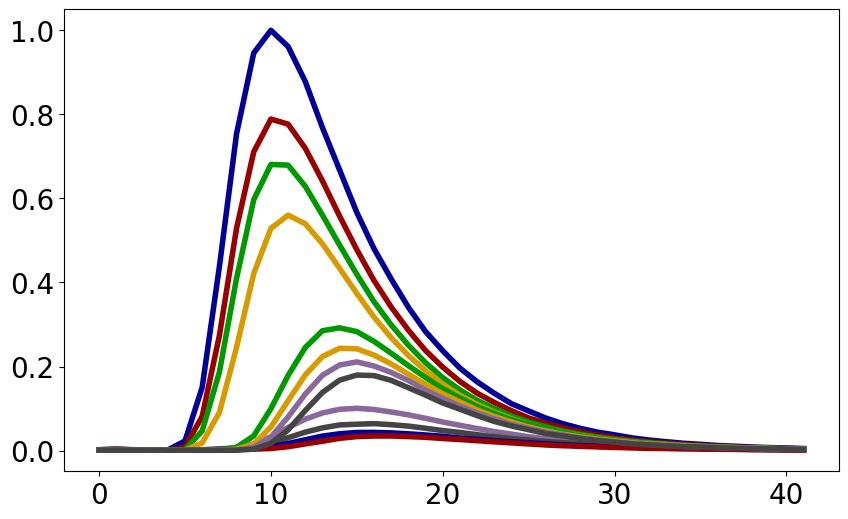

In [18]:
plt.plot(exp_data)
exp_data.shape

In [19]:
def plot_fit(time, calc_data, experimental_data):

    display.clear_output(wait=True)

    calc_data = calc_data/np.max(calc_data)
    
    res=np.sum(((calc_data.ravel()-exp_data.ravel())**2).reshape(exp_data.shape[0],exp_data.shape[1]),axis=1)
    

    fig = plt.figure(figsize=(15,5))
    ax1 = fig.add_subplot(121)
    ax1.plot(time,calc_data[:,0:4], label="mct1", color='k', linewidth=1)
    ax1.plot(time,calc_data[:,4:8], label="mct2", color='r', linewidth=1)
    ax1.plot(time,calc_data[:,8:], label="mct3", color='b', linewidth=1)
    ax1.plot(time,res, label="res", color='b')
    ax1.plot(time,experimental_data,'.')
    
    #ax1.legend()

    # ax2 = fig.add_subplot(132)

    # ax3 = fig.add_subplot(133)
    # ax3.plot(self.ssq_list, label=ssq)
    # v_text='v:'+str(v)
    # ax3.set_title(v_text)
    # ax3.legend()

    display.display(fig)
    plt.close(fig)
    
def analyze_parameters(norm_param_values, param_bounds=param_bounds):
    """
    Analyze parameters and print their names, denormalized values, and normalized values.

    Args:
        norm_param_values (list): Normalized parameter values (0-1 range).
        param_bounds (dict): Dictionary with parameter names as keys and boundary tuples as values.

    Returns:
        None: Prints the analysis.
    """
    print(f"{'Name':<30}{'Denormalized Value':<20}{'Normalized Value':<10}")
    print("-" * 65)

    # Denormalize parameters
    param_values = denormalize_parameters(norm_param_values)

    for i, (name, bounds) in enumerate(param_bounds.items()):
        value = param_values[i]
        norm_param = norm_param_values[i]

        print(f"{name:<30}{value:<20.8e}{norm_param:<10.2f}")
    

In [20]:
simulator = Cadet()    
simulator.use_dll = True
simulator.time_resolution = 60

In [21]:
simulator.check_cadet()

Test simulation completed successfully


True

In [130]:
analyze_parameters([0.57485205, 0.56823635, 0.55563725, 0.64004877, 0.44490244,
       0.30668298, 0.6293213 , 0.68179448, 0.16353874, 0.80531521,
       0.60799185])


Name                          Denormalized Value  Normalized Value
-----------------------------------------------------------------
volumetric_flow_rate_const    1.23473369e-04      0.57      
mct1_e12                      1.30055029e-03      0.57      
mct2_e12                      1.00169441e-03      0.56      
mct3_e12                      5.76021813e-03      0.64      
branch_point_side_quotia      4.05963172e-01      0.44      
col_dispersion                3.41519023e-08      0.31      
col_len                       4.68263790e-02      0.63      
t0                            7.03454429e-01      0.68      
mixer_porosity                1.55549479e-01      0.16      
branch_point_low_len          6.08347904e-02      0.81      
disp_low                      1.09637532e-06      0.61      


In [131]:
normalize_parameters([1.07458554e-04, 1.32482909e-03, 1.12723110e-03 ,2.37682273e-03,
 3.94038639e-01, 4.91695139e-08, 5.48990199e-02, 6.16724211e-01,
 1.33415255e-01 ,5.63826173e-02 ,5.41590056e-07, 7.14045093e-01,
 7.57697945e-01])


array([0.48588086, 0.56912887, 0.56133477, 0.59733298, 0.43150409,
       0.33833918, 0.66106354, 0.66811064, 0.13866883, 0.79829095,
       0.54673414])

In [132]:
denormalize_parameters([0.31662304, 0.62225708, 0.10872645, 0.63740217, 0.67730517,
       0.3971805 , 0.69147739, 0.68518598, 0.19630992, 0.7324727 ,
       0.54620982, 0.75440014, 0.79860253, 0.73416832, 0.21480205,
       0.35059962])

array([7.69921472e-05, 3.98394854e-03, 9.51783233e-08, 5.45279951e-03,
       6.12801601e-01, 9.68060500e-08, 6.39363589e-02, 7.26773665e-01,
       1.84715829e-01, 2.76609599e-02, 5.38330641e-07])

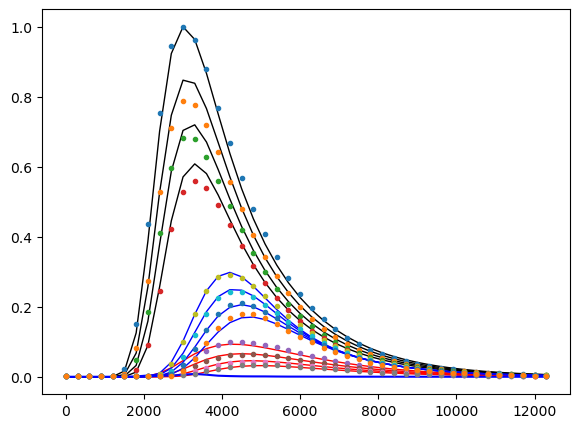

[1.23473369e-04 1.30055029e-03 1.00169441e-03 5.76021813e-03
 4.05963172e-01 3.41519023e-08 4.68263790e-02 7.03454429e-01
 1.55549479e-01 6.08347904e-02 1.09637532e-06] 4.978044173981461


(np.float64(4.978044173981461),)

In [133]:
weights = 1 / np.mean(exp_data, axis=0)
mct_obj([0.57485205, 0.56823635, 0.55563725, 0.64004877, 0.44490244,
       0.30668298, 0.6293213 , 0.68179448, 0.16353874, 0.80531521,
       0.60799185]),  

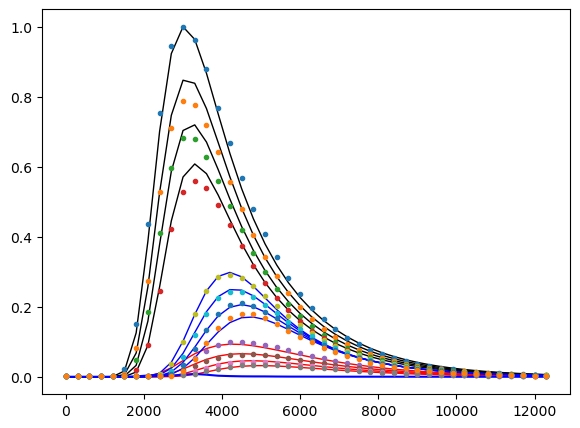

[1.23596326e-04 1.30379236e-03 9.99719665e-04 5.63100727e-03
 4.04332904e-01 3.39612588e-08 4.68275069e-02 6.96778697e-01
 1.54311235e-01 6.10824079e-02 1.08722881e-06] 4.978213966994459


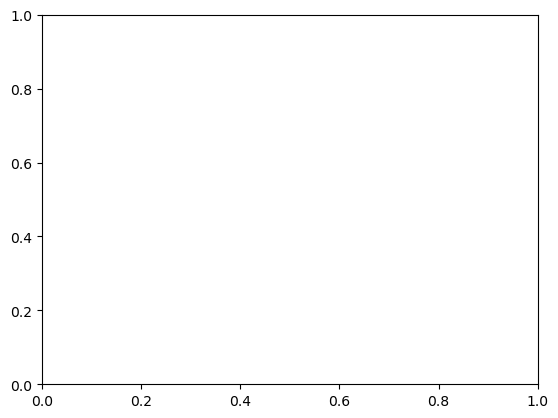

In [143]:
x0 = np.array([0.44, 0.56823635, 0.55563725, 0.64004877, 0.2,
       0.30668298, 0.6293213 , 0.68179448, 0.16353874, 0.80531521,
       0.60799185])


weights = 1 / np.mean(exp_data, axis=0)

# Initialize the plot
fig, ax = plt.subplots()

fig.canvas.draw()
display.display(fig)

result_fd = minimize(
    fun=mct_obj,
    x0=x0,
    method='L-BFGS-B',
    bounds=(11*((0,1),)),
    options={'disp': True, 'maxiter': 500, 'eps':1e-6},
    tol=1e-12)
    

In [148]:
result_fd.x

array([0.57553514, 0.56835649, 0.55554203, 0.63895401, 0.44307068,
       0.30619676, 0.62932611, 0.68080286, 0.16214746, 0.80569064,
       0.60726319])

In [52]:
# Name                          Denormalized Value  Normalized Value
# -----------------------------------------------------------------
# volumetric_flow_rate_const    1.23473369e-04      0.57      
# mct1_e12                      1.30055029e-03      0.57      
# mct2_e12                      1.00169441e-03      0.56      
# mct3_e12                      5.76021813e-03      0.64      
# branch_point_side_quotia      4.05963172e-01      0.44      
# col_dispersion                3.41519023e-08      0.31      
# col_len                       4.68263790e-02      0.63      
# t0                            7.03454429e-01      0.68      
# mixer_porosity                1.55549479e-01      0.16      
# branch_point_low_len          6.08347904e-02      0.81      
# disp_low                      1.09637532e-06      0.61 

# Parameter 0: ±1.0081356727953577%
# Parameter 1: ±0.16420631781138292%
# Parameter 2: ±0.24672201254671194%
# Parameter 3: ±2.0435147190658736%
# Parameter 4: ±1.736399267795948%
# Parameter 5: ±0.5840052977993776%
# Parameter 6: ±0.29365396752809264%
# Parameter 7: ±6.348095545525551e-16%
# Parameter 8: ±4.581689610424375%
# Parameter 9: ±0.25527408310466765%
# Parameter 10: ±1.5551750867475203%

SyntaxError: invalid syntax (3331082093.py, line 1)

In [145]:
1.23473369e-04*60000, 1.23473369e-04*60000*4.05963172e-01 , 1.23473369e-04*60000*(1-4.05963172e-01 )

(7.40840214, 3.0075384322059877, 4.400863707794012)

In [1]:
1.30055029e-03*60, 1.00169441e-03*60, 5.76021813e-03*60

(0.0780330174, 0.06010166459999999, 0.3456130878)

In [2]:
 6.08347904e-02*1000 

60.834790399999996

In [6]:

# given values
v_upper = 7.10          # mm/min
rel_err_v_upper = 0.01  # 1.0 %

q = 0.405963172         # branch quota
rel_err_q = 0.017       # 1.7 %

# absolute uncertainties
sigma_v_upper = v_upper * rel_err_v_upper
sigma_q = q * rel_err_q

# side velocity and uncertainty
v_side = v_upper * q
sigma_side = np.sqrt((q * sigma_v_upper)**2 + (v_upper * sigma_q)**2)

# lower velocity and uncertainty
v_lower = v_upper * (1 - q)
sigma_lower = np.sqrt(((1 - q) * sigma_v_upper)**2 + (v_upper * sigma_q)**2)

# relative uncertainties
rel_err_side = sigma_side / v_side
rel_err_lower = sigma_lower / v_lower

print(f"Side velocity:  {v_side:.2f} ± {sigma_side:.2f} mm/min ({rel_err_side*100:.2f} %)")
print(f"Lower velocity: {v_lower:.2f} ± {sigma_lower:.2f} mm/min ({rel_err_lower*100:.2f} %)")


Side velocity:  2.88 ± 0.06 mm/min (1.97 %)
Lower velocity: 4.22 ± 0.06 mm/min (1.53 %)


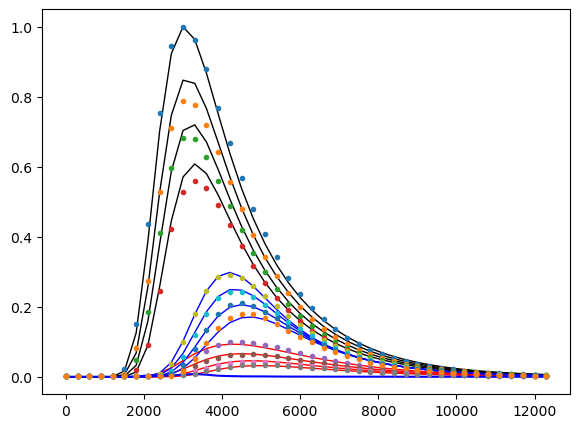

[1.23596325e-04 1.30379229e-03 9.99719746e-04 5.63100730e-03
 4.04332905e-01 3.39612604e-08 4.68275076e-02 6.96778711e-01
 1.54311239e-01 6.10824081e-02 1.08721629e-06] 4.978213742299132
Parameter 0: ±1.0081356727953577%
Parameter 1: ±0.16420631781138292%
Parameter 2: ±0.24672201254671194%
Parameter 3: ±2.0435147190658736%
Parameter 4: ±1.736399267795948%
Parameter 5: ±0.5840052977993776%
Parameter 6: ±0.29365396752809264%
Parameter 7: ±6.348095545525551e-16%
Parameter 8: ±4.581689610424375%
Parameter 9: ±0.25527408310466765%
Parameter 10: ±1.5551750867475203%


In [149]:
x_best_fit = ([0.57553514, 0.56835649, 0.55554203, 0.63895401, 0.44307068,
       0.30619676, 0.62932611, 0.68080286, 0.16214746, 0.80569064,
       0.60726319])

def compute_jacobian(f, x, eps=None):
    """Computes numerical Jacobian using central difference with adaptive epsilon."""
    x = np.asarray(x)
    n_params = len(x)
    f_x = np.asarray(f(x)).ravel()
    n_outputs = len(f_x)
    J = np.zeros((n_outputs, n_params))

    if eps is None:
        eps = np.sqrt(np.finfo(float).eps) * np.maximum(1.0, np.abs(x))

    for i in range(n_params):
        x_step = np.zeros_like(x)
        x_step[i] = eps[i]

        f_plus = np.asarray(f(x + x_step)).ravel()
        f_minus = np.asarray(f(x - x_step)).ravel()

        J[:, i] = (f_plus - f_minus) / (2 * eps[i])

    return J



# Compute the Jacobian
J = compute_jacobian(mct_obj_res, x_best_fit)

# Step 3: Compute the covariance matrix
JTJ_inv = np.linalg.pinv(J.T @ J)
sigma_squared = np.var(mct_obj_res(x_best_fit))  # Estimate variance of residuals
C = JTJ_inv * sigma_squared  # Covariance matrix

# Step 4: Compute parameter uncertainties
param_uncertainties = np.sqrt(np.abs(np.diag(C)))  # Extract uncertainties
rel_param_uncertanties = param_uncertainties / np.abs(x_best_fit)

# Print results
for i, uncertainty in enumerate(rel_param_uncertanties):
    print(f"Parameter {i}: ±{uncertainty*100}%")

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.lines import Line2D

# --- helper to lighten/darken a color ---
def shade(color, factor=1.0):
    r, g, b = to_rgb(color)
    if factor >= 1.0:  # lighten toward white
        f = min(factor - 1.0, 1.0)
        return (r + (1 - r)*f, g + (1 - g)*f, b + (1 - b)*f)
    else:              # darken toward black
        f = max(1.0 - factor, 0.0)
        return (r*(1 - f), g*(1 - f), b*(1 - f))

def plot_pretty(x_norm):

    x = denormalize_parameters(x_norm)
    process = setup_process(x)

    simulation_results = simulator.simulate(process)
    time_new = np.arange(t[0]*60, t[-1]*60 + 60, 60)
    x_calc_min = time_new / 60.0  # minutes

    mct1 = process.flow_sheet.units[2]
    mct2 = process.flow_sheet.units[3]
    mct3 = process.flow_sheet.units[4]

    lengths_up   = [xx / 1000 for xx in xi_up]
    lengths_side = [xx / 1000 for xx in xi_side]
    lengths_low  = [xx / 1000 for xx in xi_low]

    cb_mct1 = interpolate_cb_from_simulation_results(
        simulation_results, mct1, time_new,
        axial_positions_new=lengths_up
    )
    cb_mct2 = interpolate_cb_from_simulation_results(
        simulation_results, mct2, time_new,
        axial_positions_new=lengths_side
    )
    cb_mct3 = interpolate_cb_from_simulation_results(
        simulation_results, mct3, time_new,
        axial_positions_new=lengths_low
    )

    calc_data = np.hstack((
        np.sum(cb_mct1, axis=2).squeeze(),
        np.sum(cb_mct2, axis=2).squeeze(),
        np.sum(cb_mct3, axis=2).squeeze()
    ))
    calc_data = calc_data / np.max(calc_data)

    plt.style.use('default')

    # fixed branch colors
    branch_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Upper, Side, Lower
    branch_slices = [slice(0, 4), slice(4, 8), slice(8, calc_data.shape[1])]
    branch_labels = ["Upper ROI 1–4", "Side ROI 5–8", "Lower ROI 9–12"]
    branch_markers = ['o', 's', '^']  # branch-level markers
    roi_markers    = ['o', 's', '^', 'D']  # ROI-level markers

    # =========================
    # General plot (all branches)
    # =========================
    plt.figure(figsize=(6,5))
    plt.xticks(fontsize=14); plt.yticks(fontsize=14)
    plt.xlabel("Time [min]", fontsize=15)
    plt.ylabel("Activity [a.u.]", fontsize=15)

    legend_handles = []
    for slc, lab, col, mk in zip(branch_slices, branch_labels, branch_colors, branch_markers):
        # simulated (solid)
        plt.plot(x_calc_min, calc_data[:, slc], color=col, linewidth=1.5)
        # experimental (hollow)
        plt.plot(t, exp_data[:, slc], linestyle='None', marker=mk,
                 markersize=6, markerfacecolor='none', markeredgecolor=col, alpha=0.6)
        # proxy handle for legend
        legend_handles.append(
            Line2D([], [], color=col, linewidth=1.5,
                   marker=mk, markersize=7, markerfacecolor='none',
                   markeredgecolor=col, label=lab)
        )

    plt.legend(handles=legend_handles, fontsize=12)  
    plt.savefig("mct_general_fit.pdf", format="pdf")

    # =========================
    # Branch-specific subplots
    # =========================
    def plot_branch(col_slice, title, base_color):
        plt.figure(figsize=(6,5))
        plt.xticks(fontsize=12); plt.yticks(fontsize=12)
        plt.xlabel("Time [min]", fontsize=15)
        plt.ylabel("Activity [a.u.]", fontsize=15)
        plt.title(title, fontsize=16)

        n_roi = col_slice.stop - col_slice.start
        shade_factors = np.linspace(0.7, 1.3, n_roi)  # gentle shades

        handles = []
        for j, i in enumerate(range(col_slice.start, col_slice.stop)):
            roi_idx = i - col_slice.start + 1
            mk = roi_markers[j % len(roi_markers)]
            col_j = shade(base_color, shade_factors[j])

            # simulated (solid)
            plt.plot(x_calc_min, calc_data[:, i], linewidth=1.8, color=col_j)
            # experimental (hollow)
            plt.plot(t, exp_data[:, i], linestyle='None', marker=mk,
                     markersize=6, markerfacecolor='none', markeredgecolor=col_j)

            # proxy handle
            handles.append(
                Line2D([], [], color=col_j, linewidth=1.8,
                       marker=mk, markersize=7, markerfacecolor='none',
                       markeredgecolor=col_j, label=f"ROI {roi_idx}")
            )

        plt.legend(handles=handles, fontsize=12, ncol=2)
        #plt.savefig("mct_upper.pdf", format="pdf")
        

    #plot_branch(slice(0, 4), "", branch_colors[0])
    #plot_branch(slice(4, 8), "",  branch_colors[1])
    #plot_branch(slice(8, calc_data.shape[1]), "", branch_colors[2])



/home/IBT/lanzrath/CADET/CADET-Process/CADETProcess/processModel/unitOperation.py:396: UserWarning: Detected Bulk Reaction Model. Attempt casting to Particle Reaction Model.
  warnings.warn(
Exception ignored on calling ctypes callback function: <function param_provider_get_double_array_item at 0x794ff2b823e0>
Traceback (most recent call last):
  File "/home/IBT/lanzrath/CADET/CADET-Python/cadet/cadet_dll_utils.py", line 329, in param_provider_get_double_array_item
    float_val = float(o[index])
                      ~^^^^^^^
  File "/home/IBT/lanzrath/CADET/CADET-Process/CADETProcess/dataStructure/dataStructure.py", line 98, in __getitem__
    return self._get_values_from_aggregator()[index]
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^
IndexError: list index out of range
Exception ignored on calling ctypes callback function: <function param_provider_get_double_array_item at 0x794ff2b823e0>
Traceback (most recent call last):
  File "/home/IBT/lanzrath/CADET/CADET-Python/cadet/

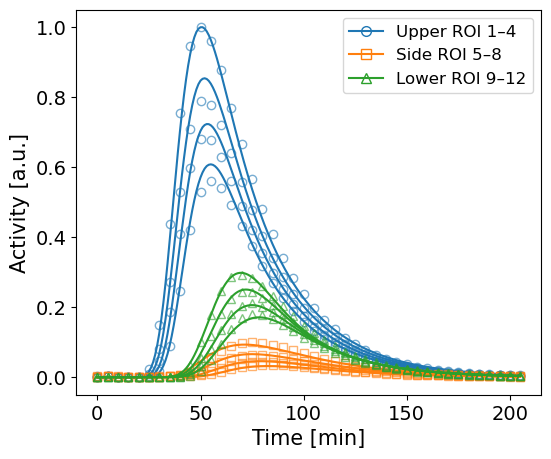

In [81]:
plot_pretty([0.57485205, 0.56823635, 0.55563725, 0.64004877, 0.44490244,
       0.30668298, 0.6293213 , 0.68179448, 0.16353874, 0.80531521,
       0.60799185])

In [137]:
calc = mct_obj_data([0.57485205, 0.56823635, 0.55563725, 0.64004877, 0.44490244,
       0.30668298, 0.6293213 , 0.68179448, 0.16353874, 0.80531521,
       0.60799185])


C:\Users\h.lanzrath\CADET\CADET-Process\CADETProcess\processModel\unitOperation.py:396: UserWarning: Detected Bulk Reaction Model. Attempt casting to Particle Reaction Model.
  warnings.warn(
Exception ignored on calling ctypes callback function: <function param_provider_get_double_array_item at 0x0000018FE3A914E0>
Traceback (most recent call last):
  File "C:\Users\h.lanzrath\CADET\CADET-Python\cadet\cadet_dll_utils.py", line 329, in param_provider_get_double_array_item
    float_val = float(o[index])
                      ~^^^^^^^
  File "C:\Users\h.lanzrath\CADET\CADET-Process\CADETProcess\dataStructure\dataStructure.py", line 98, in __getitem__
    return self._get_values_from_aggregator()[index]
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^
IndexError: list index out of range
Exception ignored on calling ctypes callback function: <function param_provider_get_double_array_item at 0x0000018FE3A914E0>
Traceback (most recent call last):
  File "C:\Users\h.lanzrath\CADET\CADET-P

t_ci shape: (4, 3)
Velocities (m/s): [np.float64(0.00012975459789827906), np.float64(5.4730654077506146e-05), np.float64(6.123162770037408e-05)]
Velocities (mm/min): [np.float64(7.785275873896743), np.float64(3.283839244650369), np.float64(3.673897662022445)]
Relative errors (fraction): [np.float64(0.014561851931521276), np.float64(0.0063962394504685945), np.float64(0.02438557745629589)]
Relative errors (%): [np.float64(1.4561851931521275), np.float64(0.6396239450468595), np.float64(2.438557745629589)]


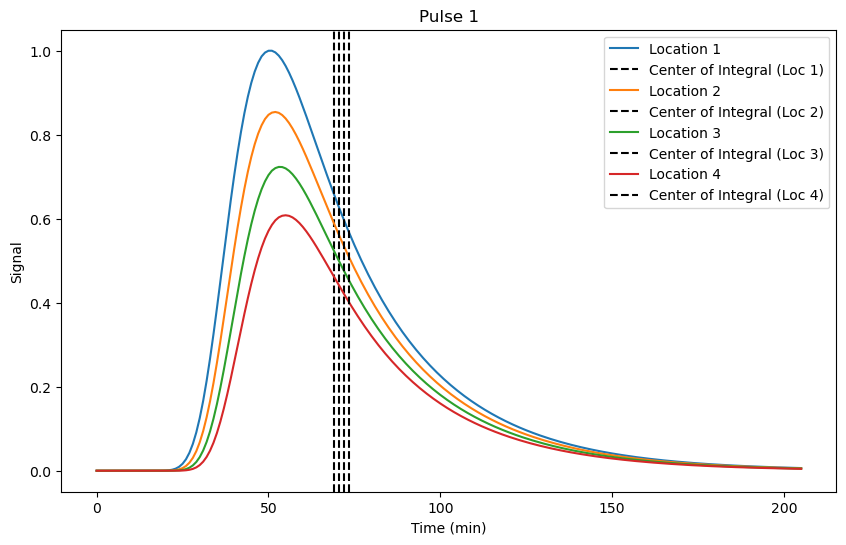

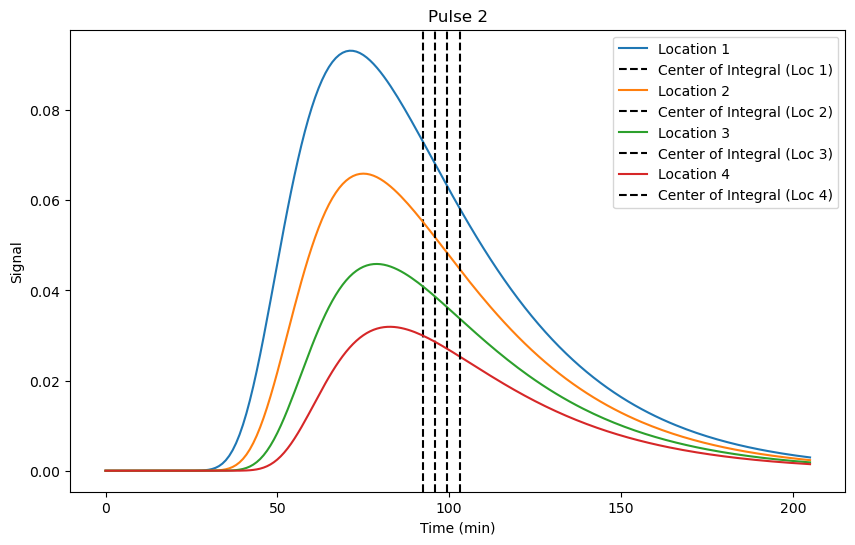

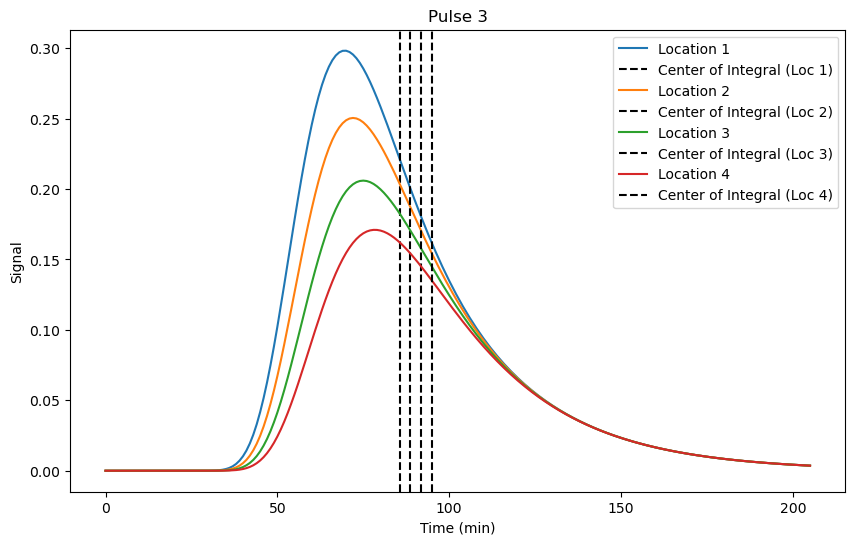

In [138]:

n_times = 206
t_50int = np.linspace(0, 60*t[-1], n_times)  # 205 minutes 

# Reshape data
signals = calc.reshape(n_times, 3, 4)
signals = signals.transpose(0, 2, 1)

# Compute center of integral
t_ci = np.sum(t_50int[:, None, None] * signals, axis=0) / np.sum(signals, axis=0)
print("t_ci shape:", t_ci.shape)

xi_list = np.array([xi_up, xi_side, xi_low])/1000
# Fit for each pulse
velocities = []
velocity_errors = []

for i in range(3):
    x_i = xi_list[i]
    t_i = t_ci[:, i]

    # Fit line AND get covariance
    coeffs, cov = np.polyfit(t_i, x_i, 1, cov=True)
    v = coeffs[0]
    velocities.append(v)

    SE = np.sqrt(cov[0,0])
    rel_error = SE / abs(v)
    velocity_errors.append(rel_error)

print("Velocities (m/s):", velocities)
print("Velocities (mm/min):", [v * 60000 for v in velocities])
print("Relative errors (fraction):", velocity_errors)
print("Relative errors (%):", [100 * e for e in velocity_errors])


for pulse_idx in range(3):
    plt.figure(figsize=(10, 6))
    for loc_idx in range(4):
        plt.plot(t_50int / 60, signals[:, loc_idx, pulse_idx], label=f'Location {loc_idx+1}')
        # Draw vertical line for t_ci for this location
        plt.axvline(t_ci[loc_idx, pulse_idx] / 60,
                    color='k', linestyle='--',
                    label=f'Center of Integral (Loc {loc_idx+1})')
    plt.title(f'Pulse {pulse_idx+1}')
    plt.xlabel('Time (min)')
    plt.ylabel('Signal')
    plt.legend()
    plt.show()

t_m1 shape: (4, 3)
Velocities (m/s): [1.20313612e-04 3.97514812e-05 6.17905906e-05]
Velocities (mm/min): [7.21881671 2.38508887 3.70743544]
Relative errors (fraction): [np.float64(0.014532789567718331), np.float64(0.009898112448747174), np.float64(0.03207813450695749)]
Relative errors (%): [1.45327896 0.98981124 3.20781345]


c:/Users/h.lanzrath/CADET/Files/tmp\ipykernel_27804\3770750151.py:3: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  num = np.trapz(t_50int[:, None, None] * signals, x=t_50int, axis=0)    # shape: (n_locs, n_pulses)
c:/Users/h.lanzrath/CADET/Files/tmp\ipykernel_27804\3770750151.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  den = np.trapz(signals,                          x=t_50int, axis=0)    # shape: (n_locs, n_pulses)


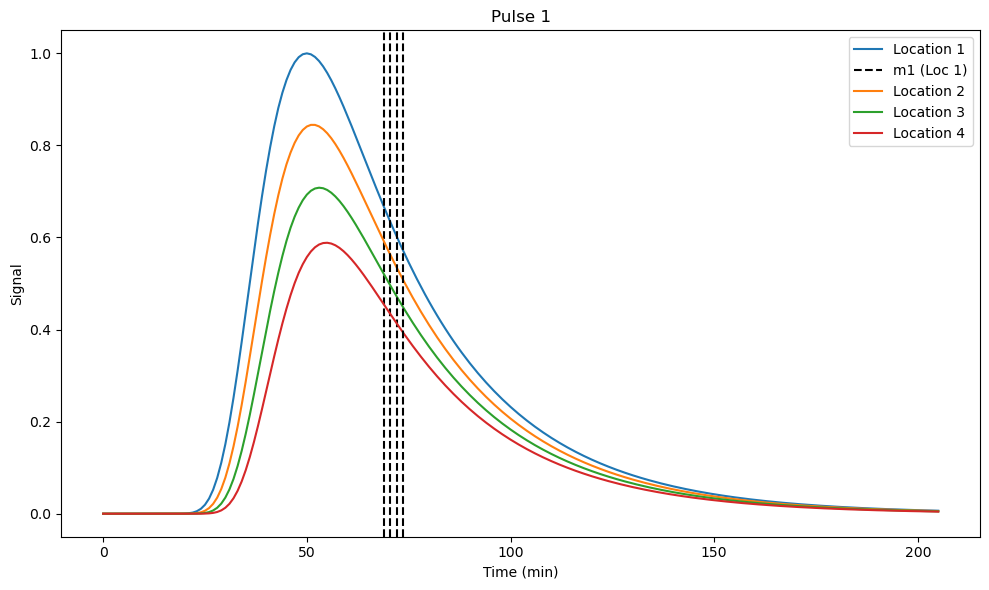

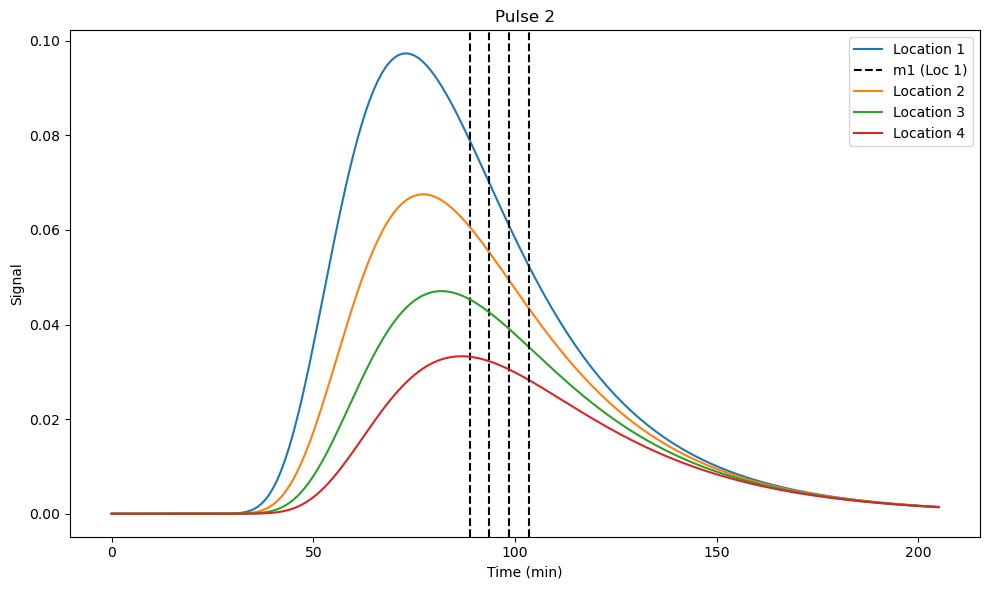

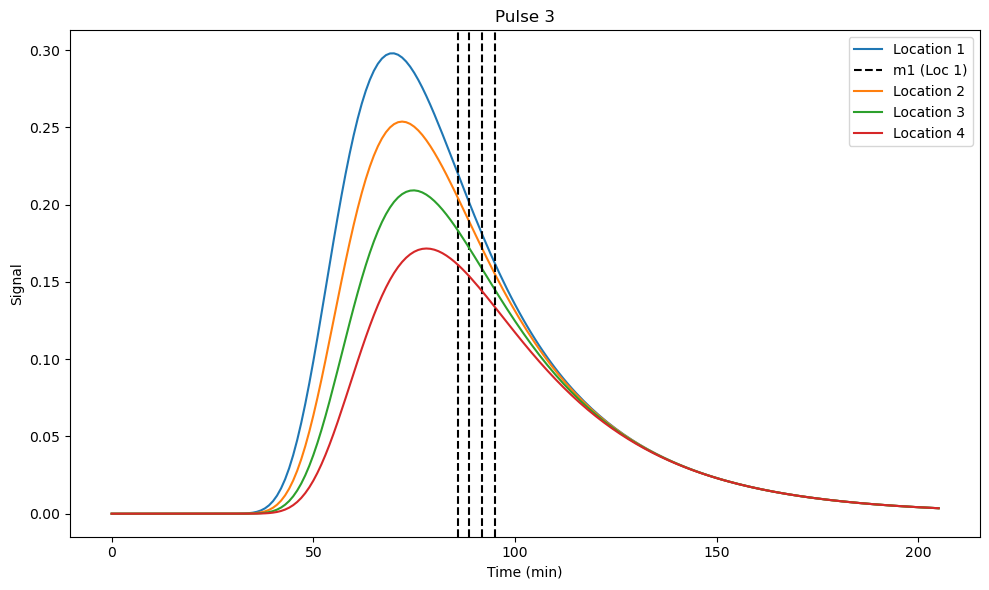

In [ ]:


# --- 1) First moment (mean arrival time) using trapezoidal rule ---
# m1 = ∫ t * y(t) dt / ∫ y(t) dt
num = np.trapz(t_50int[:, None, None] * signals, x=t_50int, axis=0)    # shape: (n_locs, n_pulses)
den = np.trapz(signals,                          x=t_50int, axis=0)    # shape: (n_locs, n_pulses)

# Guard against division by ~0
eps = np.finfo(float).tiny
t_m1 = num / np.clip(den, eps, None)  # shape: (n_locs, n_pulses)

print("t_m1 shape:", t_m1.shape)  # (n_locs, n_pulses)

# --- 2) Prepare positions for each pulse (meters) ---
xi_list = np.array([xi_up, xi_side, xi_low]) / 1000.0  # shape: (n_pulses, n_locs)
# If your pulse order differs, reorder either xi_list or t_m1 accordingly.

# --- 3) Fit x = v * t + b for each pulse; get covariance and relative error ---
velocities = []
velocity_errors = []

n_pulses = xi_list.shape[0]
for i in range(n_pulses):
    x_i = np.asarray(xi_list[i])          # meters, shape (n_locs,)
    t_i = np.asarray(t_m1[:, i])          # seconds, shape (n_locs,)

    # linear fit with covariance: coeffs[0] = slope = v (m/s)
    coeffs, cov = np.polyfit(t_i, x_i, deg=1, cov=True)
    v = coeffs[0]
    velocities.append(v)

    SE = np.sqrt(cov[0, 0])              # std error of slope
    rel_error = SE / (abs(v) if v != 0 else np.nan)
    velocity_errors.append(rel_error)

# --- 4) Report results ---
velocities = np.array(velocities)  # m/s
vel_mm_min = velocities * 60_000   # mm/min
rel_err_pct = np.array(velocity_errors) * 100

print("Velocities (m/s):", velocities)
print("Velocities (mm/min):", vel_mm_min)
print("Relative errors (fraction):", velocity_errors)
print("Relative errors (%):", rel_err_pct)

# --- 5) (Optional) visualize each pulse with its first-moment time marks ---
for pulse_idx in range(n_pulses):
    plt.figure(figsize=(10, 6))
    for loc_idx in range(signals.shape[1]):
        plt.plot(t_50int / 60.0, signals[:, loc_idx, pulse_idx], label=f'Location {loc_idx+1}')
        plt.axvline(t_m1[loc_idx, pulse_idx] / 60.0, color='k', linestyle='--',
                    label=f'm1 (Loc {loc_idx+1})' if loc_idx == 0 else None)
    plt.title(f'Pulse {pulse_idx+1}')
    plt.xlabel('Time (min)')
    plt.ylabel('Signal')
    plt.legend()
    plt.tight_layout()
    plt.show()
